In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns

In [22]:
df=pd.read_csv("D:\Dataset\quikr_car.csv")
df.head(10)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel
7,Hyundai Eon,Hyundai,2013,"1,90,000","25,000 kms",Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,"8,30,000","24,530 kms",Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,"2,50,000","60,000 kms",Petrol


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [24]:
df["name"].str.split()

0        [Hyundai, Santro, Xing, XO, eRLX, Euro, III]
1                        [Mahindra, Jeep, CL550, MDI]
2                    [Maruti, Suzuki, Alto, 800, Vxi]
3      [Hyundai, Grand, i10, Magna, 1.2, Kappa, VTVT]
4              [Ford, EcoSport, Titanium, 1.5L, TDCi]
                            ...                      
887                                              [Ta]
888                          [Tata, Zest, XM, Diesel]
889                            [Mahindra, Quanto, C8]
890                   [Honda, Amaze, 1.2, E, i, VTEC]
891                   [Chevrolet, Sail, 1.2, LT, ABS]
Name: name, Length: 892, dtype: object

In [34]:
df['name']=df["name"].str.split().str.get(0)
df['name'].head()

0     Hyundai
1    Mahindra
2      Maruti
3     Hyundai
4        Ford
Name: name, dtype: object

In [35]:
print(df.isnull().sum())


name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64


In [36]:
df_drop=df.dropna()
print(df_drop)
df.info()

          name    company    year     Price    kms_driven fuel_type
0      Hyundai    Hyundai  2007.0   80000.0  45000.000000    Petrol
1     Mahindra   Mahindra  2006.0  425000.0     40.000000    Diesel
2       Maruti     Maruti  2018.0  299999.0  22000.000000    Petrol
3      Hyundai    Hyundai  2014.0  325000.0  28000.000000    Petrol
4         Ford       Ford  2014.0  575000.0  36000.000000    Diesel
..         ...        ...     ...       ...           ...       ...
887         Ta       Tara  2013.0  310000.0  46010.550119    Petrol
888       Tata       Tata  2018.0  260000.0  27000.000000    Diesel
889   Mahindra   Mahindra  2013.0  390000.0  40000.000000    Diesel
890      Honda      Honda  2014.0  180000.0  46010.550119    Petrol
891  Chevrolet  Chevrolet  2014.0  160000.0  46010.550119    Petrol

[892 rows x 6 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------    

In [47]:
# Convert year column to numeric, invalid entries become NaN
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Fill missing years if you want (e.g., with median or mode)
df['year'] = df['year'].fillna(df['year'].median())
df.head(60) 

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai,Hyundai,2007.0,80000.0,45000.0,Petrol
1,Mahindra,Mahindra,2006.0,425000.0,40.0,Diesel
2,Maruti,Maruti,2018.0,299999.0,22000.0,Petrol
3,Hyundai,Hyundai,2014.0,325000.0,28000.0,Petrol
4,Ford,Ford,2014.0,575000.0,36000.0,Diesel
5,Ford,Ford,2015.0,299999.0,59000.0,Diesel
6,Ford,Ford,2012.0,175000.0,41000.0,Diesel
7,Hyundai,Hyundai,2013.0,190000.0,25000.0,Petrol
8,Ford,Ford,2016.0,830000.0,24530.0,Diesel
9,Maruti,Maruti,2015.0,250000.0,60000.0,Petrol


In [49]:
df['Price'] = df['Price'].astype(str) 

# Step 1: Remove commas
df['Price'] = df['Price'].str.replace(',', '', regex=False)

df['Price'] = df['Price'].str.strip()

# Step 2: Replace text like "ask for price" with NaN
df['Price'] = df['Price'].replace(['ask for price', 'Ask for Price'], None)

# Step 3: Convert to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Step 4: Fill missing values (choose mean/median depending on your data)
df['Price'] = df['Price'].fillna(df['Price'].median())
df.info() 
df  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        892 non-null    object 
 1   company     892 non-null    object 
 2   year        892 non-null    float64
 3   Price       892 non-null    float64
 4   kms_driven  892 non-null    float64
 5   fuel_type   892 non-null    object 
dtypes: float64(3), object(3)
memory usage: 41.9+ KB


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai,Hyundai,2007.0,80000.0,45000.000000,Petrol
1,Mahindra,Mahindra,2006.0,425000.0,40.000000,Diesel
2,Maruti,Maruti,2018.0,299999.0,22000.000000,Petrol
3,Hyundai,Hyundai,2014.0,325000.0,28000.000000,Petrol
4,Ford,Ford,2014.0,575000.0,36000.000000,Diesel
...,...,...,...,...,...,...
887,Ta,Tara,2013.0,310000.0,46010.550119,Petrol
888,Tata,Tata,2018.0,260000.0,27000.000000,Diesel
889,Mahindra,Mahindra,2013.0,390000.0,40000.000000,Diesel
890,Honda,Honda,2014.0,180000.0,46010.550119,Petrol


In [50]:
# Start from the raw column (assuming you still have it as object/string)
df['kms_driven'] = df['kms_driven'].astype(str)  # force to string

# Remove 'kms' and commas
df['kms_driven'] = df['kms_driven'].str.replace('kms', '', regex=False) 
df['kms_driven'] = df['kms_driven'].str.replace(',', '', regex=False) 

# Strip spaces
df['kms_driven'] = df['kms_driven'].str.strip() 

# Convert to numeric
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce') 

# Fill missing values
df['kms_driven'] = df['kms_driven'].fillna(df['kms_driven'].mean()) 
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        892 non-null    object 
 1   company     892 non-null    object 
 2   year        892 non-null    float64
 3   Price       892 non-null    float64
 4   kms_driven  892 non-null    float64
 5   fuel_type   892 non-null    object 
dtypes: float64(3), object(3)
memory usage: 41.9+ KB


In [57]:
df['fuel_type']=df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df.info()
df['fuel_type']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        892 non-null    object 
 1   company     892 non-null    object 
 2   year        892 non-null    float64
 3   Price       892 non-null    float64
 4   kms_driven  892 non-null    float64
 5   fuel_type   892 non-null    object 
dtypes: float64(3), object(3)
memory usage: 41.9+ KB


0      Petrol
1      Diesel
2      Petrol
3      Petrol
4      Diesel
        ...  
887    Petrol
888    Diesel
889    Diesel
890    Petrol
891    Petrol
Name: fuel_type, Length: 892, dtype: object

In [58]:
print(df.isnull().sum())

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64


In [64]:
# Save cleaned DataFrame to a new CSV file
df.to_csv("D:\Dataset\quikr_car1.csv", index=False)

Text(0.5, 1.0, 'bar Graph')

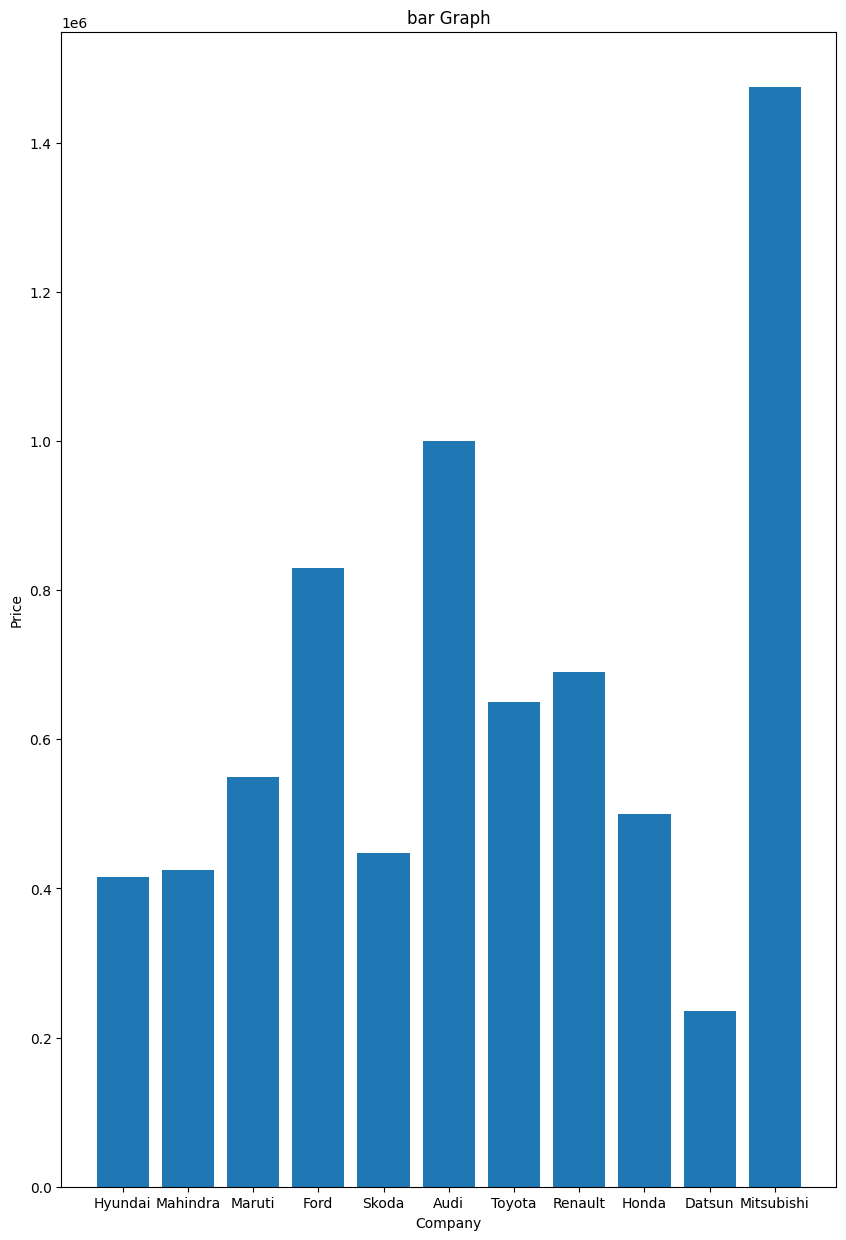

In [74]:
x=df["company"].head(50)
y=df["Price"].head(50)
plt.figure(figsize=(10,15))
plt.bar(x,y)
plt.xlabel("Company")
plt.ylabel("Price")
plt.title("bar Graph")

Text(0.5, 1.0, 'Price Distribution By Company')

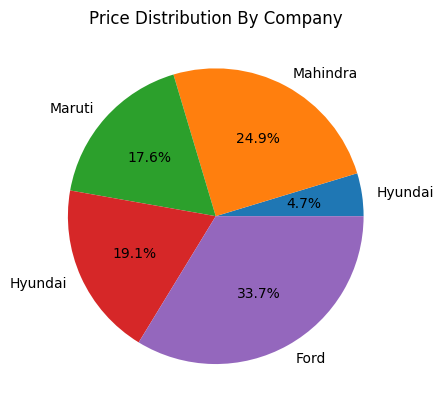

In [72]:
x=df["company"].head(5)
y=df["Price"].head(5)
plt.pie(y,labels=x,autopct='%1.1f%%')
plt.title("Price Distribution By Company")

In [84]:
h=df["company"].value_counts().head(10)
h

company
Maruti        237
Hyundai       145
Mahindra      100
Tata           78
Honda          61
Toyota         39
Chevrolet      35
Renault        34
Ford           31
Volkswagen     20
Name: count, dtype: int64

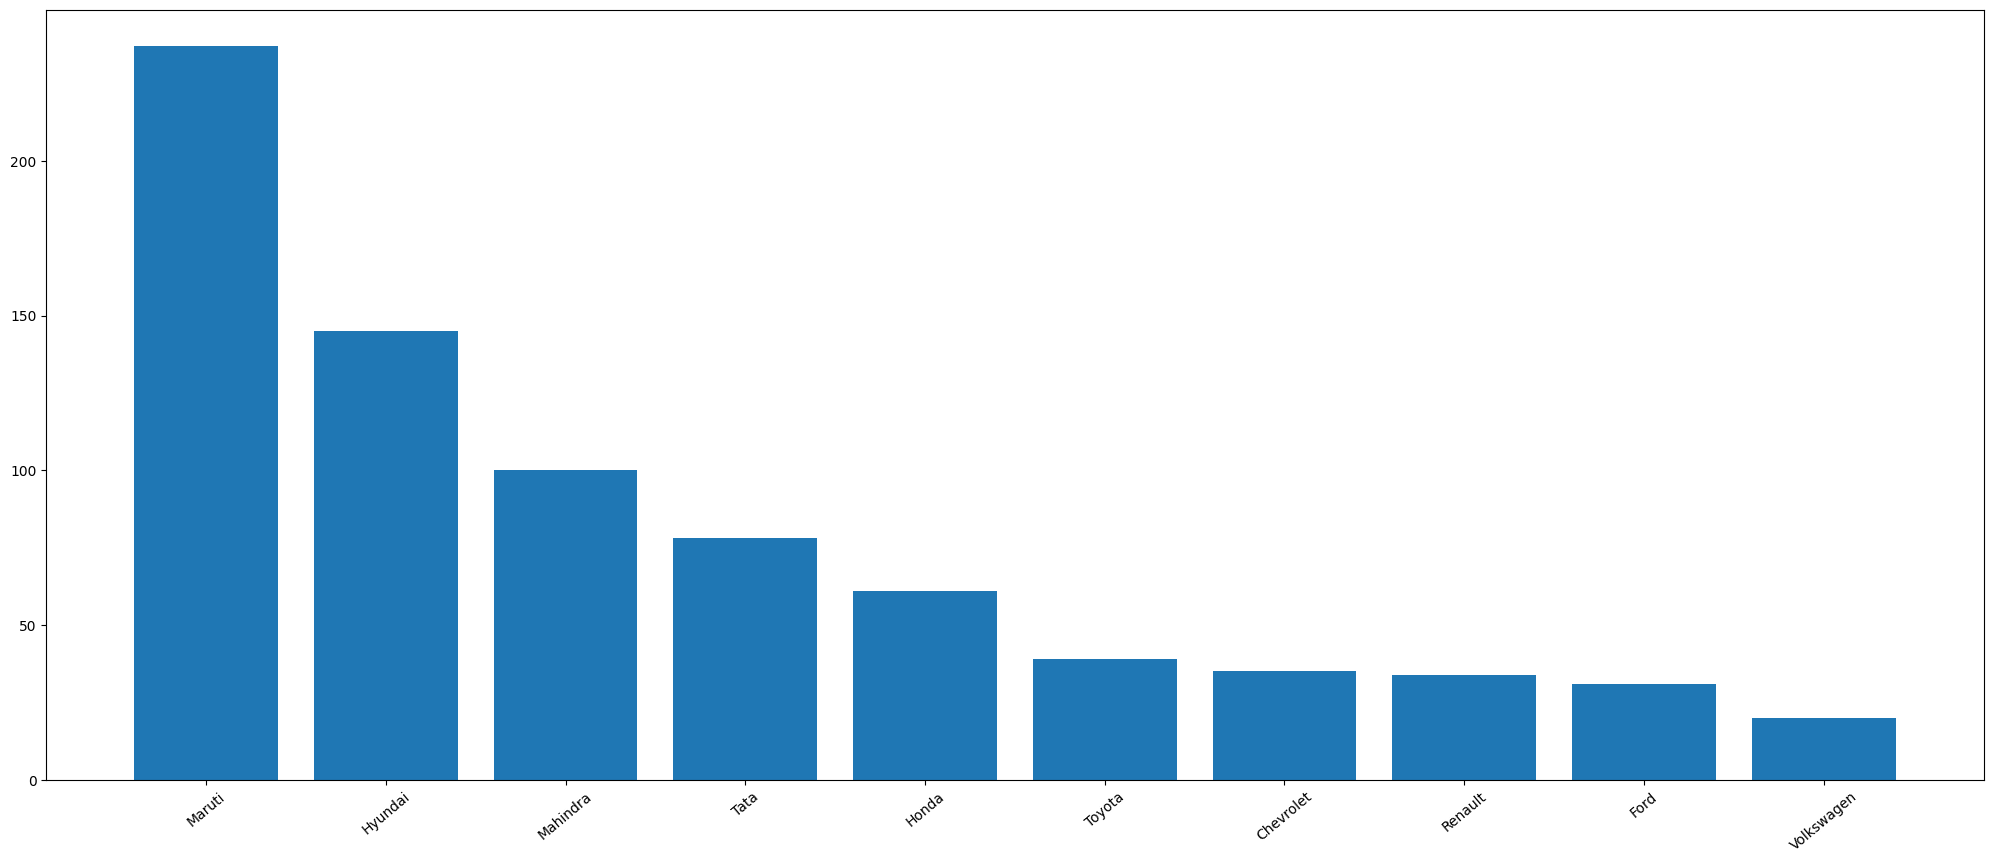

In [85]:
x=h.keys()
y=h
plt.figure(figsize=(25,10))
plt.bar(x,y)
plt.xticks(rotation=40)
plt.show()

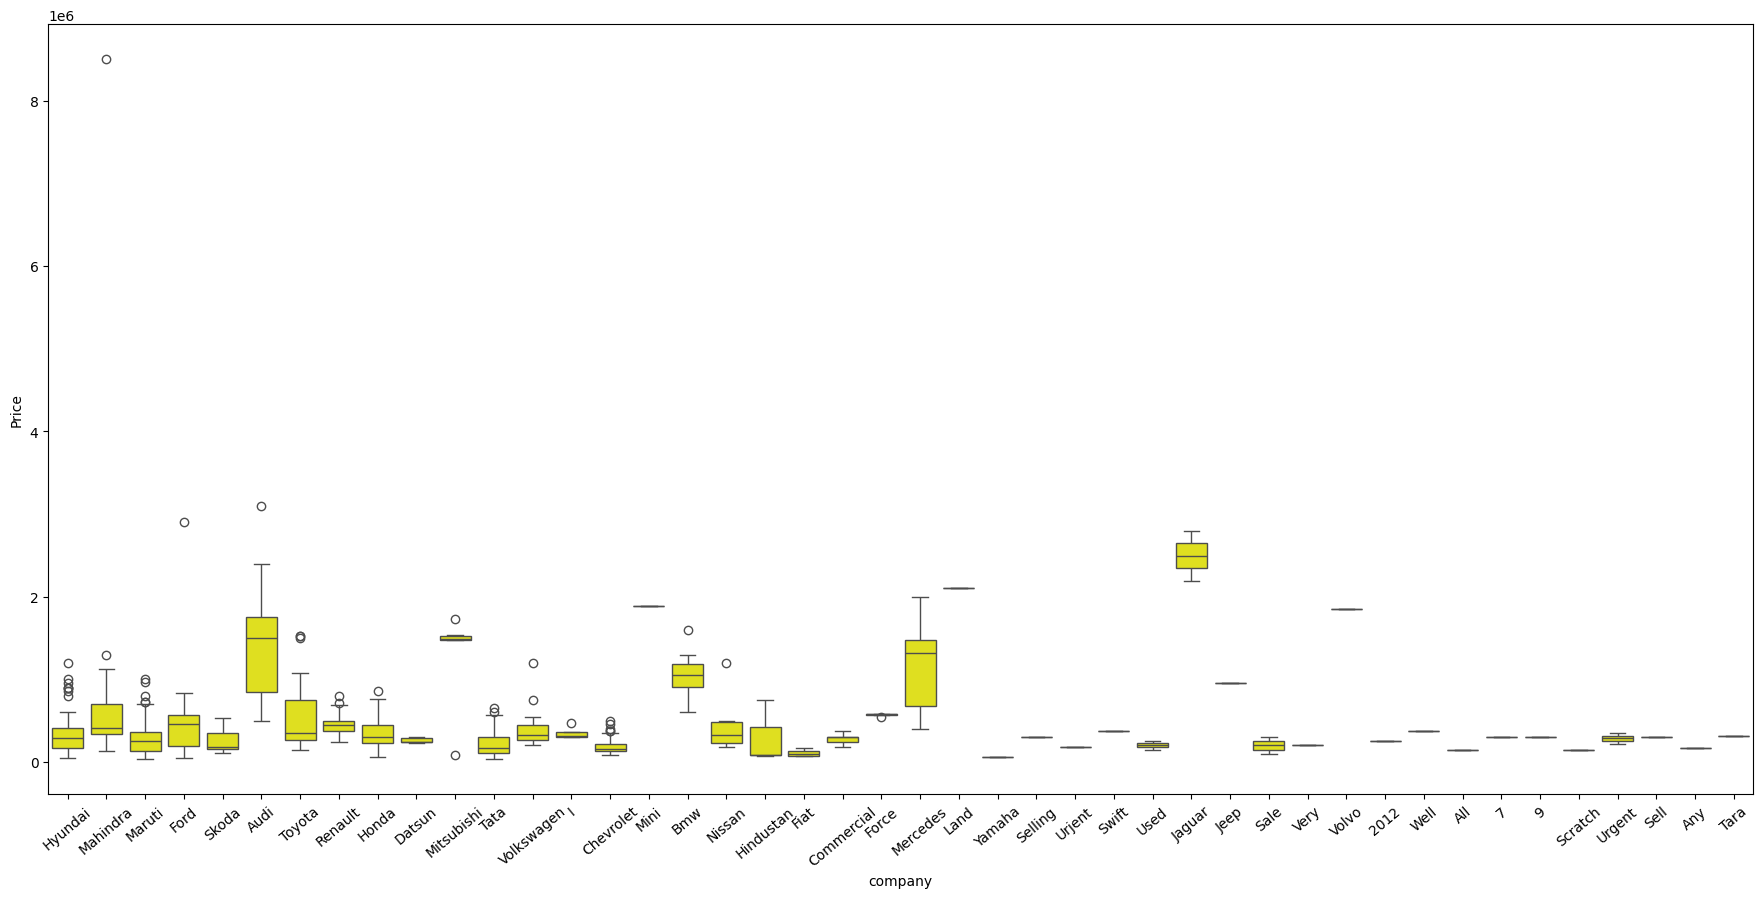

In [89]:
plt.figure(figsize=(22,10))
sns.boxplot(x="company",y="Price",data=df,color="yellow")
plt.xticks(rotation=40)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_2572\590263112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="company", y="Price", data=df, palette="Set2")


<Axes: xlabel='company', ylabel='Price'>

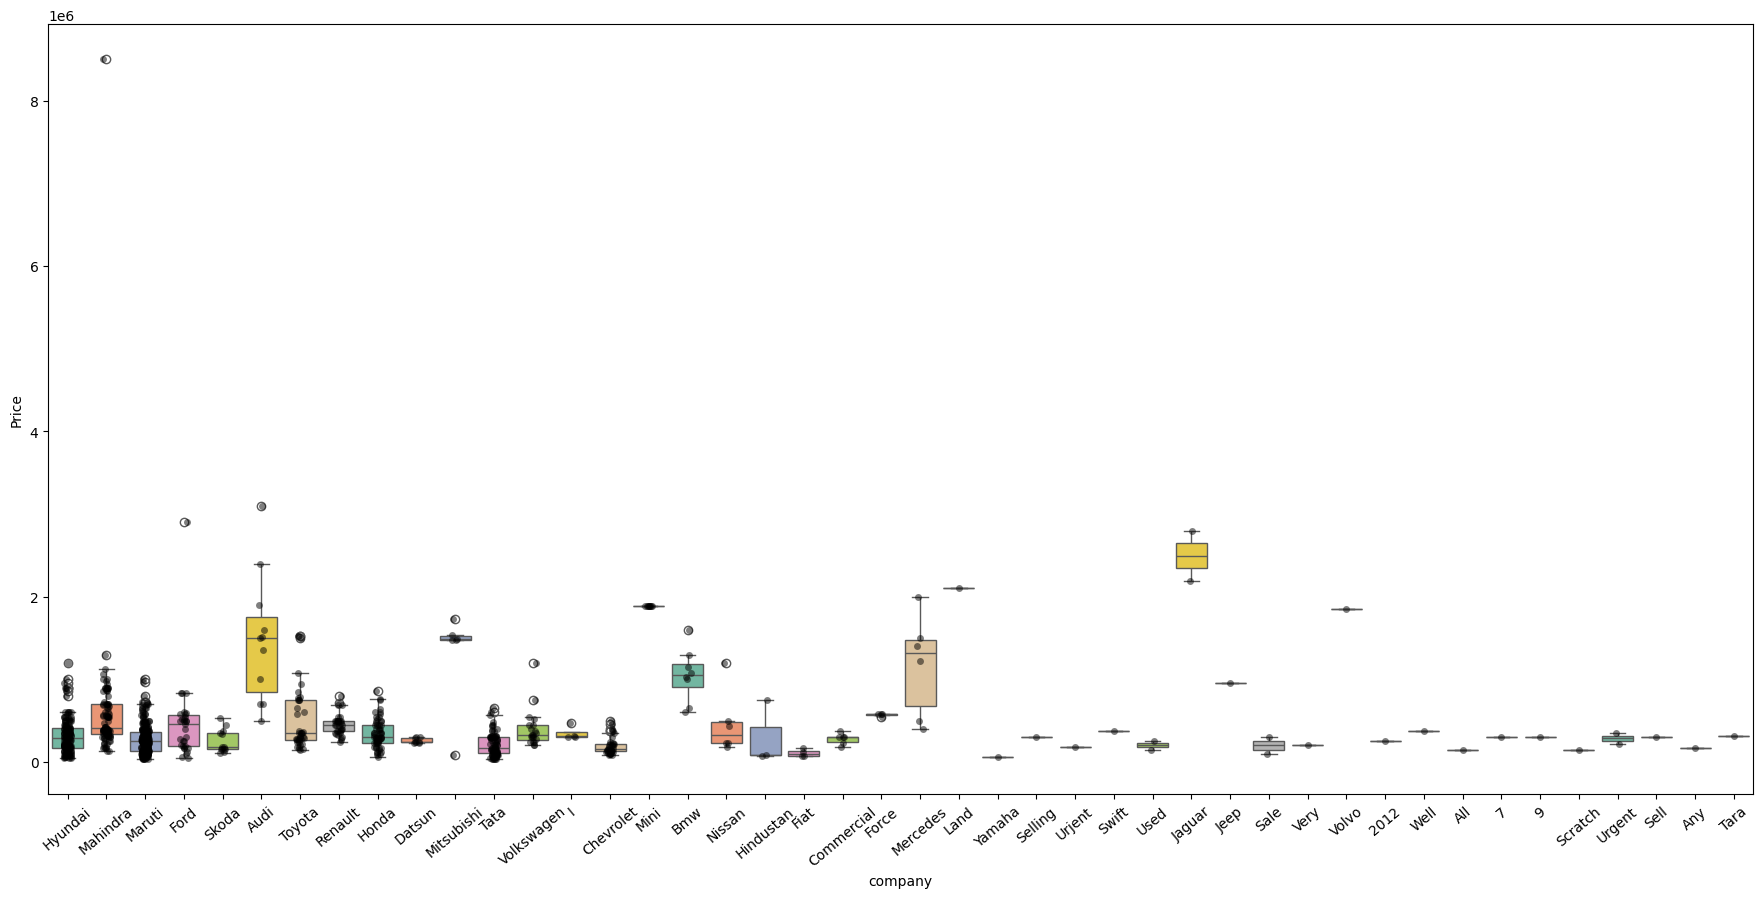

In [93]:
plt.figure(figsize=(22,10))
plt.xticks(rotation=40)
sns.boxplot(x="company", y="Price", data=df, palette="Set2")
sns.stripplot(x="company", y="Price", data=df, color="black", alpha=0.5)


In [75]:
df["company"] = df["company"].str.strip().str.title()

In [76]:
df["company"].value_counts()

company
Maruti        237
Hyundai       145
Mahindra      100
Tata           78
Honda          61
Toyota         39
Chevrolet      35
Renault        34
Ford           31
Volkswagen     20
Skoda          13
Audi           11
Mini            8
Datsun          8
Bmw             8
Mitsubishi      6
Nissan          6
Commercial      6
Mercedes        6
I               4
Force           4
Fiat            4
Hindustan       3
Used            2
Urgent          2
Sale            2
Jaguar          2
Land            1
Swift           1
Urjent          1
Selling         1
Yamaha          1
Very            1
Volvo           1
2012            1
Jeep            1
Well            1
All             1
9               1
7               1
Scratch         1
Sell            1
Any             1
Tara            1
Name: count, dtype: int64

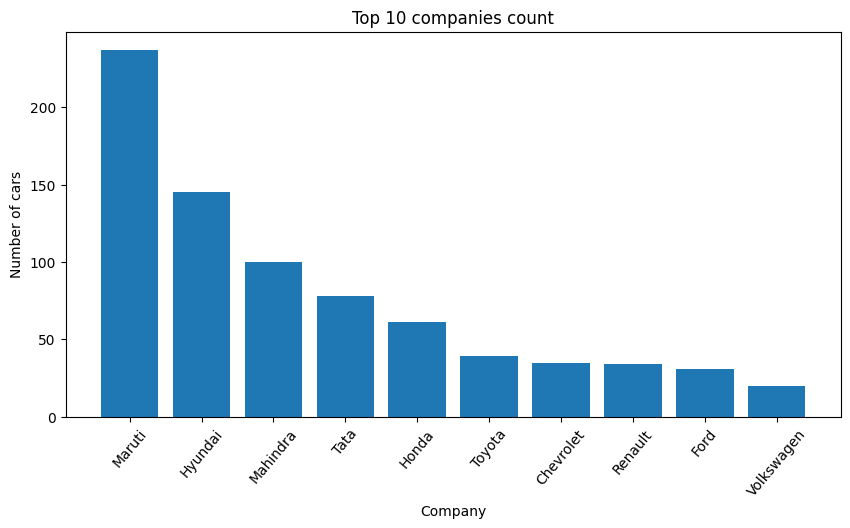

In [87]:
h = df["company"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(h.index, h.values)
plt.xticks(rotation=50)
plt.title("Top 10 companies count")
plt.xlabel("Company")
plt.ylabel("Number of cars")
plt.show()